# Employee Attrition Analysis and Prediction.

### IS 4007 - Individual Activity
### K.K.N.Himara (s16905)

#### 1) Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

PALETTE = ['#2E86AB', '#1D3557']
print('Libraries loaded successfully.')

Libraries loaded successfully.


#### 2) Load and Inspect the Dataset.

In [3]:
#Load Dataset
df = pd.read_csv("Employee_Attrition_DataSet.csv")

In [4]:
df.head()

,EmployeeID,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,EMP0000,42,Sales,3,9,9866,4,1,No,24.5,Yes,4,19,No
1,EMP0001,36,Sales,3,7,8958,3,3,No,10.0,No,2,13,No
2,EMP0002,44,Sales,4,16,11716,4,3,No,4.0,No,4,13,No
3,EMP0003,53,Finance,4,30,17061,5,3,No,7.1,No,3,20,No
4,EMP0004,35,HR,2,4,5738,2,3,No,8.4,No,2,15,No


In [5]:
print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())

Shape: (10000, 14)

Column names: ['EmployeeID', 'Age', 'Department', 'JobLevel', 'YearsAtCompany', 'MonthlyIncome', 'JobSatisfaction', 'WorkLifeBalance', 'OverTime', 'DistanceFromHome', 'PromotionLast5Years', 'PerformanceRating', 'TrainingHoursLastYear', 'Attrition']


In [6]:
# Data types
df.dtypes

EmployeeID                object
Age                        int64
Department                object
JobLevel                   int64
YearsAtCompany             int64
MonthlyIncome              int64
JobSatisfaction            int64
WorkLifeBalance            int64
OverTime                  object
DistanceFromHome         float64
PromotionLast5Years       object
PerformanceRating          int64
TrainingHoursLastYear      int64
Attrition                 object
dtype: object

In [7]:
# Summary statistics
df.describe()

,Age,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,DistanceFromHome,PerformanceRating,TrainingHoursLastYear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,37.693500,2.380800,7.788400,8967.918800,3.362100,2.761500,9.91074,2.603800,14.993100
std,9.376457,1.141368,7.141941,3500.745748,1.059951,0.893027,6.97463,0.737889,3.886227
min,22.000000,1.000000,0.000000,3000.000000,1.000000,1.000000,1.00000,1.000000,2.000000
25%,31.000000,1.000000,2.000000,6043.500000,3.000000,2.000000,4.70000,2.000000,12.000000
50%,37.000000,2.000000,6.000000,8670.000000,3.000000,3.000000,8.30000,3.000000,15.000000
75%,44.000000,3.000000,12.000000,11484.000000,4.000000,3.000000,13.40000,3.000000,18.000000
max,60.000000,5.000000,35.000000,21410.000000,5.000000,4.000000,50.00000,4.000000,31.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             10000 non-null  object 
 1   Age                    10000 non-null  int64  
 2   Department             10000 non-null  object 
 3   JobLevel               10000 non-null  int64  
 4   YearsAtCompany         10000 non-null  int64  
 5   MonthlyIncome          10000 non-null  int64  
 6   JobSatisfaction        10000 non-null  int64  
 7   WorkLifeBalance        10000 non-null  int64  
 8   OverTime               10000 non-null  object 
 9   DistanceFromHome       10000 non-null  float64
 10  PromotionLast5Years    10000 non-null  object 
 11  PerformanceRating      10000 non-null  int64  
 12  TrainingHoursLastYear  10000 non-null  int64  
 13  Attrition              10000 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 1.1+ M

#### 3) Data Preprocessing

In [9]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\nNo missing values found — dataset is clean.')

Missing values per column:
EmployeeID               0
Age                      0
Department               0
JobLevel                 0
YearsAtCompany           0
MonthlyIncome            0
JobSatisfaction          0
WorkLifeBalance          0
OverTime                 0
DistanceFromHome         0
PromotionLast5Years      0
PerformanceRating        0
TrainingHoursLastYear    0
Attrition                0
dtype: int64

No missing values found — dataset is clean.


In [10]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

Duplicate rows: 0


In [11]:
# Attrition target distribution
print('\nAttrition value counts:')
print(df['Attrition'].value_counts())
print('\nAttrition percentage:')
print(df['Attrition'].value_counts(normalize=True) * 100)


Attrition value counts:
Attrition
No     9097
Yes     903
Name: count, dtype: int64

Attrition percentage:
Attrition
No     90.97
Yes     9.03
Name: proportion, dtype: float64


In [12]:
# Verify categorical variable levels
cat_cols = ['Department', 'OverTime', 'PromotionLast5Years', 'Attrition']
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

Department: ['Sales' 'Finance' 'HR' 'IT' 'Engineering' 'Operations' 'Marketing']
OverTime: ['No' 'Yes']
PromotionLast5Years: ['Yes' 'No']
Attrition: ['No' 'Yes']


In [13]:
# Ordinal variables levels
ord_cols = ['JobLevel', 'JobSatisfaction', 'WorkLifeBalance', 'PerformanceRating']
for col in ord_cols:
    print(f'{col}: {sorted(df[col].unique())}')

JobLevel: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
JobSatisfaction: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
WorkLifeBalance: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
PerformanceRating: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


#### 4) Exploratory Data Analysis (EDA)

##### 4.1) Attrition Distribution

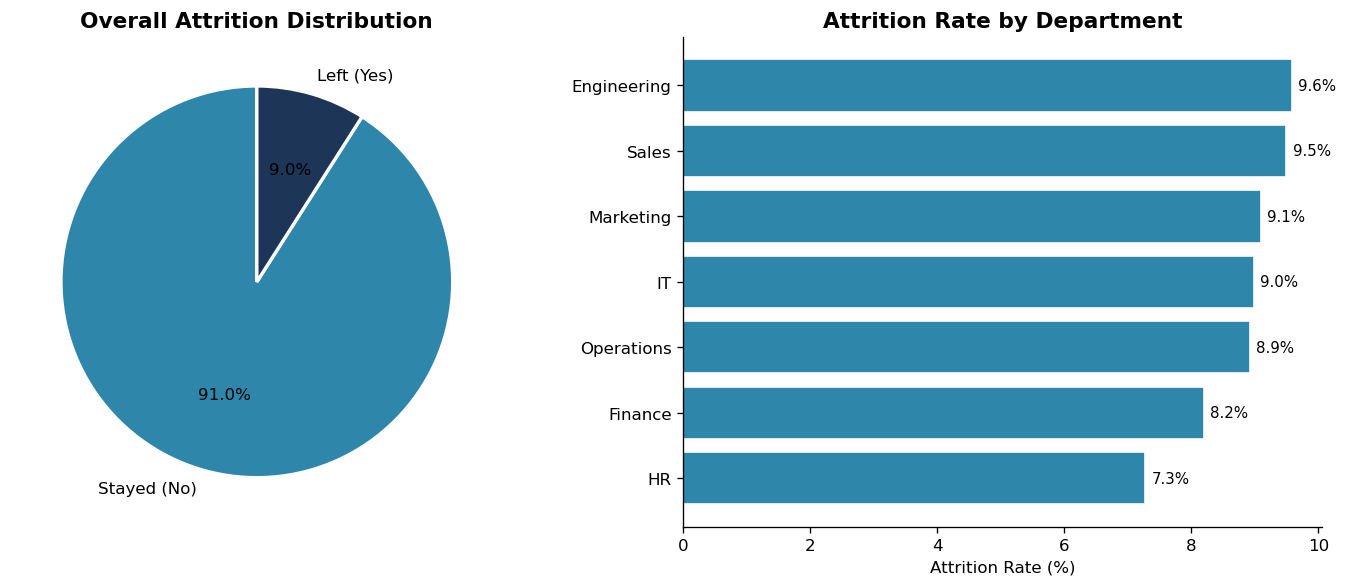

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
counts = df['Attrition'].value_counts()
axes[0].pie(counts, labels=['Stayed (No)', 'Left (Yes)'], autopct='%1.1f%%',
            colors=PALETTE, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Overall Attrition Distribution', fontsize=13, fontweight='bold')

# Attrition rate by Department
dept_attr = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=True)
bars = axes[1].barh(dept_attr.index, dept_attr.values, color='#2E86AB', edgecolor='white')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
for bar, val in zip(bars, dept_attr.values):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

##### 4.2) Numerical Featurea vs Attrition

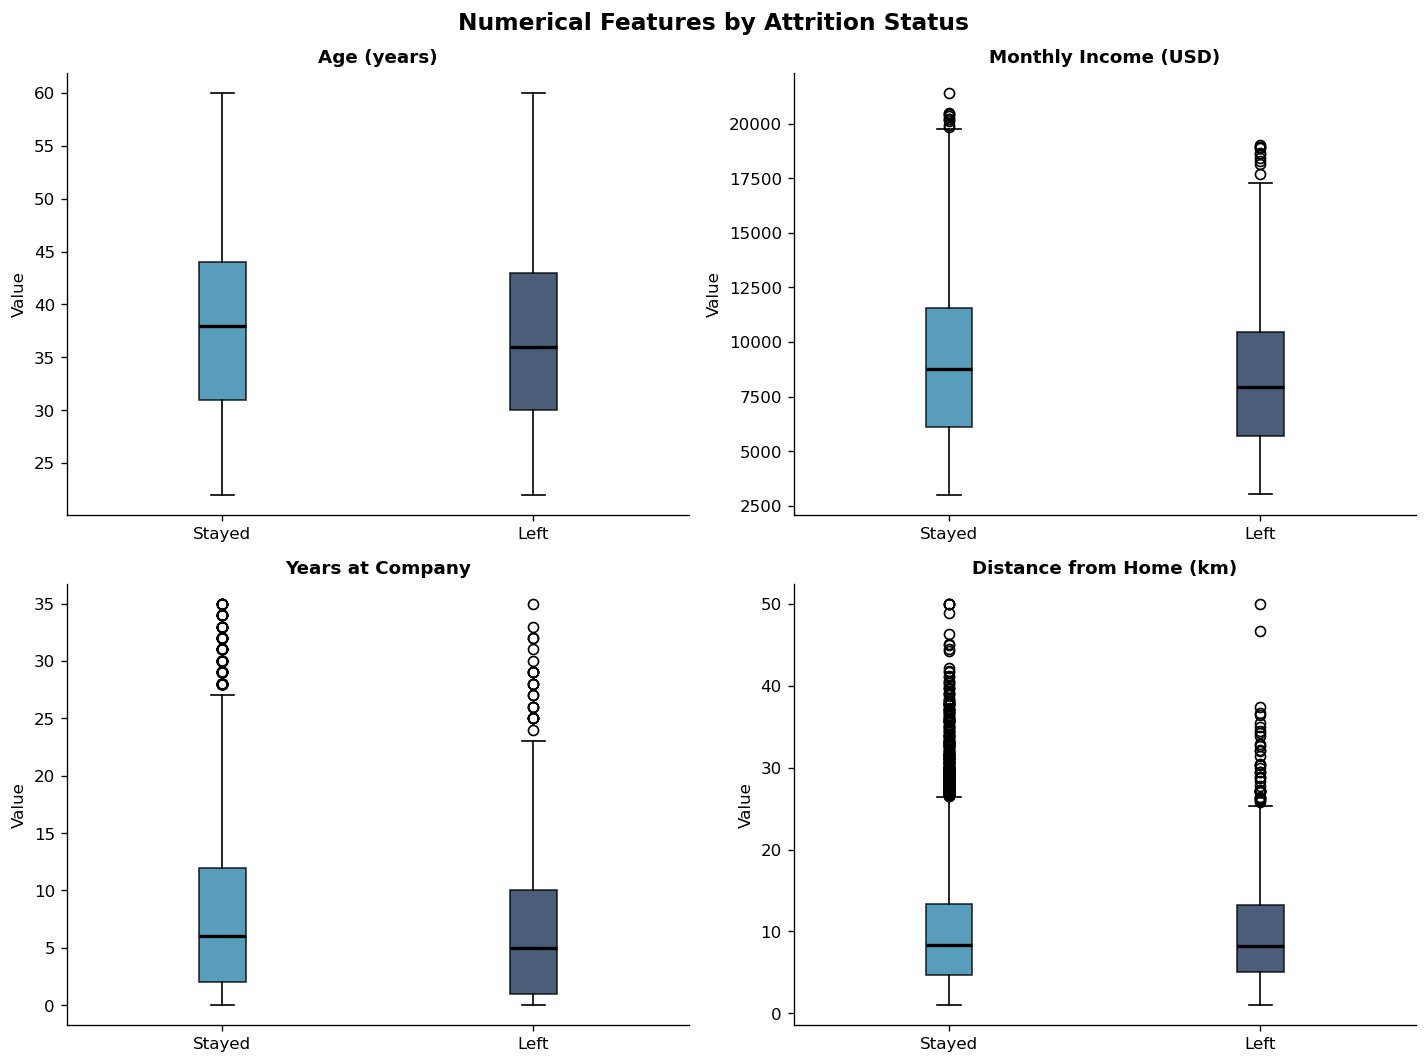

In [15]:
num_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome']
titles   = ['Age (years)', 'Monthly Income (USD)', 'Years at Company', 'Distance from Home (km)']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Numerical Features by Attrition Status', fontsize=14, fontweight='bold')

for ax, col, title in zip(axes.flat, num_cols, titles):
    groups = [df[df['Attrition'] == 'No'][col], df[df['Attrition'] == 'Yes'][col]]
    bp = ax.boxplot(groups, labels=['Stayed', 'Left'], patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

In [16]:
# Summary statistics by Attrition group
print('Mean values by Attrition status:')
df.groupby('Attrition')[num_cols].mean().round(2)

Mean values by Attrition status:


,Age,MonthlyIncome,YearsAtCompany,DistanceFromHome
Attrition,,,,
No,37.81,9032.83,7.92,9.91
Yes,36.54,8313.99,6.49,9.88


##### 4.3) Categorical Features vs Attrition

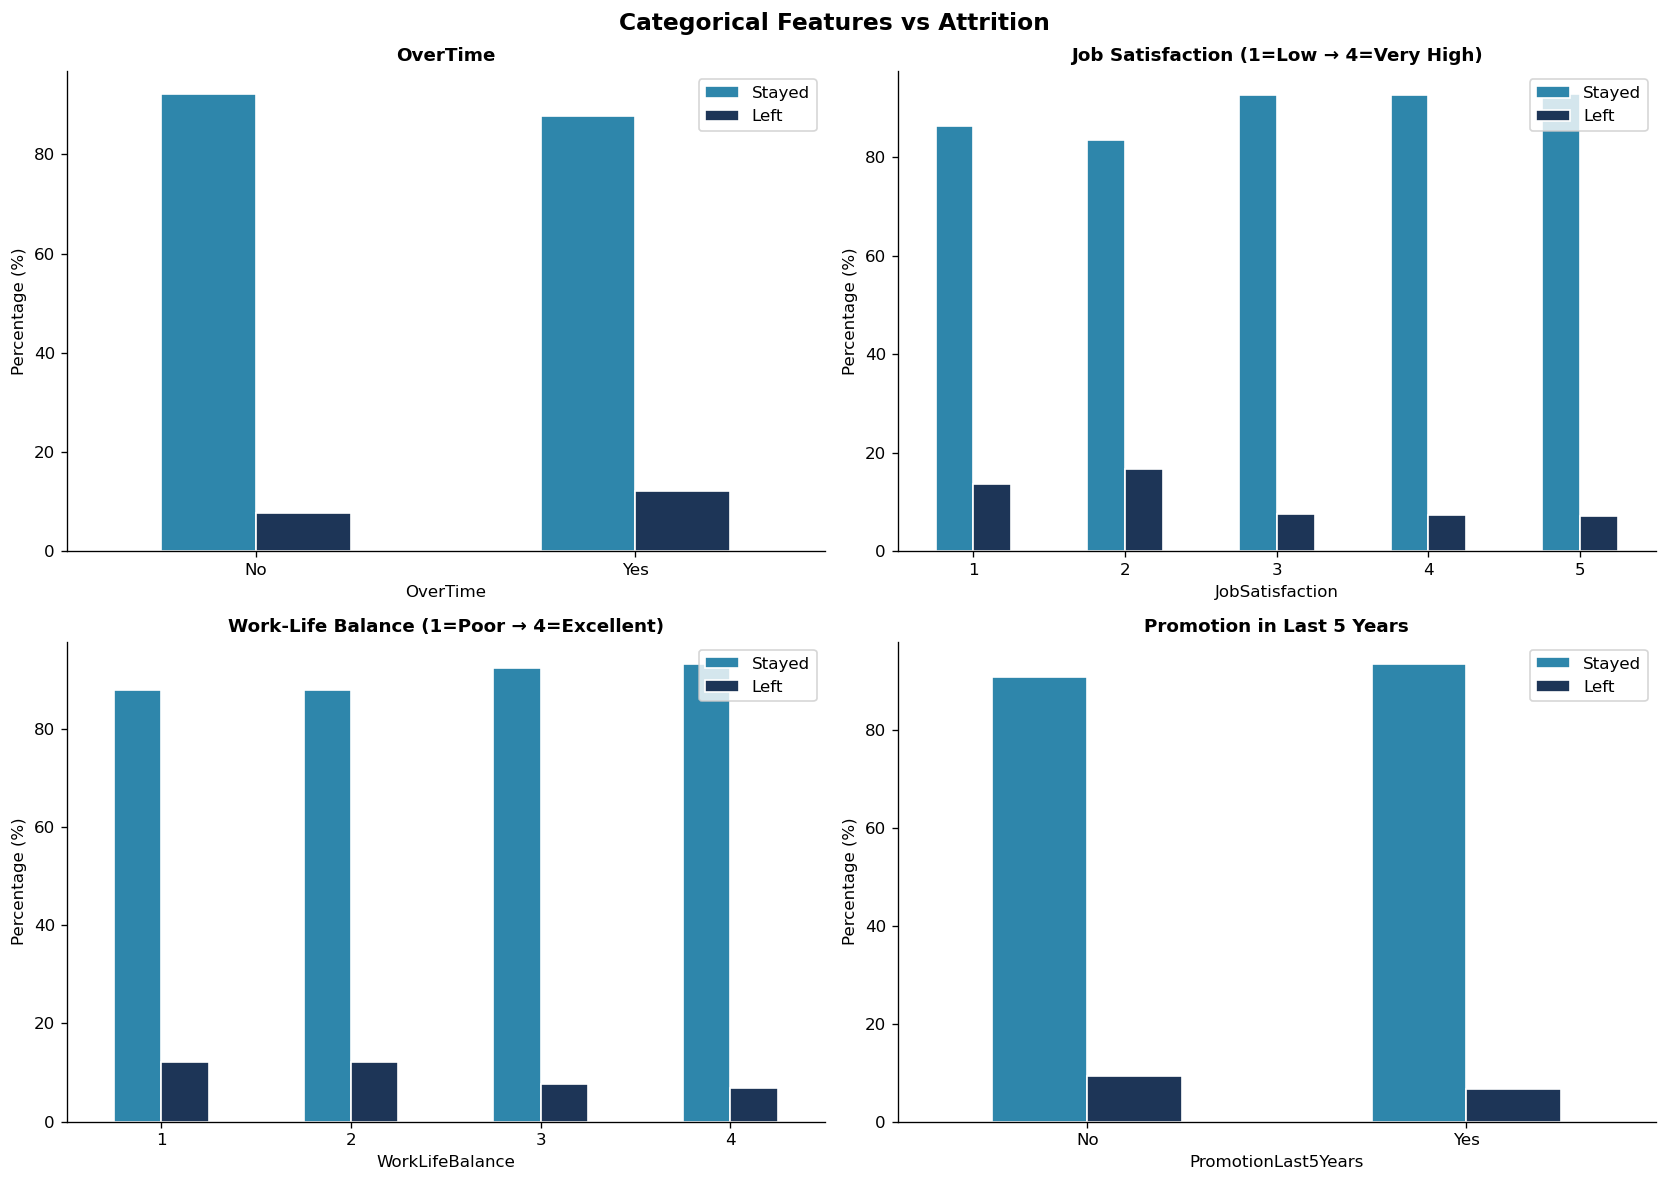

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Categorical Features vs Attrition', fontsize=14, fontweight='bold')

cat_plot_cols = ['OverTime', 'JobSatisfaction', 'WorkLifeBalance', 'PromotionLast5Years']
cat_titles    = ['OverTime', 'Job Satisfaction (1=Low → 4=Very High)',
                 'Work-Life Balance (1=Poor → 4=Excellent)', 'Promotion in Last 5 Years']

for ax, col, title in zip(axes.flat, cat_plot_cols, cat_titles):
    grp = df.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    grp_pct = grp.div(grp.sum(axis=1), axis=0) * 100
    grp_pct.plot(kind='bar', ax=ax, color=PALETTE, rot=0, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.legend(['Stayed', 'Left'])

plt.tight_layout()
plt.show()

In [18]:
# Attrition rates for key categorical variables
print('Attrition rate by OverTime:')
print(df.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(2))

print('\nAttrition rate by Promotion:')
print(df.groupby('PromotionLast5Years')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(2))

print('\nAttrition rate by JobLevel:')
print(df.groupby('JobLevel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(2))

print('\nAttrition rate by JobLevel:')
print(df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(2))

Attrition rate by OverTime:
OverTime
No      7.78
Yes    12.18
Name: Attrition, dtype: float64

Attrition rate by Promotion:
PromotionLast5Years
No     9.27
Yes    6.67
Name: Attrition, dtype: float64

Attrition rate by JobLevel:
JobLevel
1    11.22
2     9.17
3     9.16
4     5.04
5     5.18
Name: Attrition, dtype: float64

Attrition rate by JobLevel:
WorkLifeBalance
1    12.11
2    12.13
3     7.60
4     6.87
Name: Attrition, dtype: float64


##### 4.4) Correlation Matrix

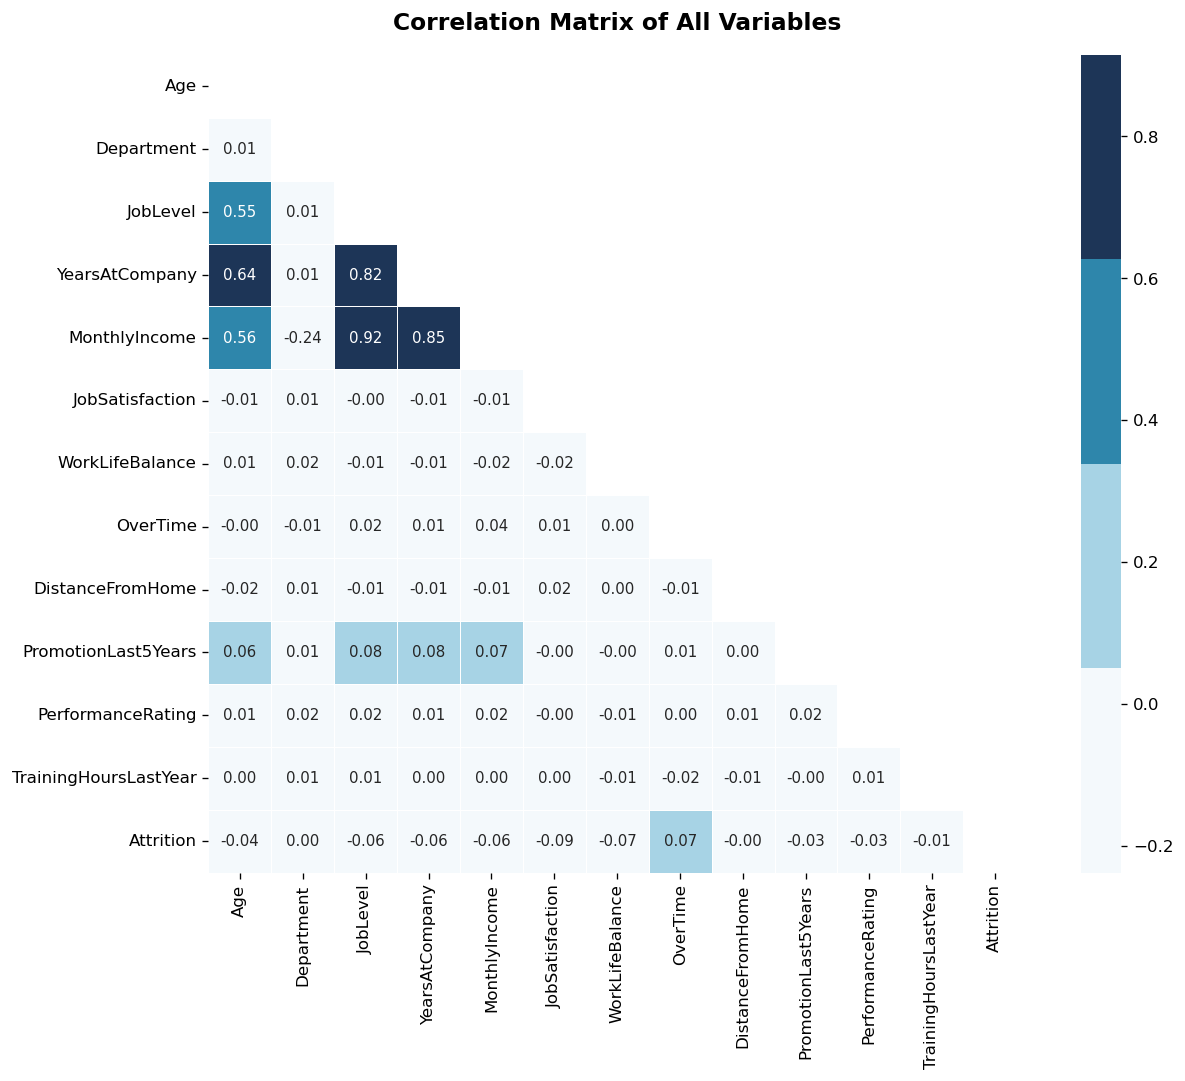

In [19]:
df_corr = df.copy()
le_tmp = LabelEncoder()
for col in ['OverTime', 'PromotionLast5Years', 'Attrition', 'Department']:
    df_corr[col] = le_tmp.fit_transform(df_corr[col])
df_corr = df_corr.drop('EmployeeID', axis=1)

corr = df_corr.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',  cmap=sns.color_palette(
        ['#F4F9FC', '#A7D3E5', '#2E86AB', '#1D3557'],
        as_cmap=True
    ),
            ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix of All Variables', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [20]:
# ── Correlation with Attrition (sorted)
print("=== Pearson Correlation with Attrition (sorted) ===")
attrition_corr = df_corr.corr()['Attrition'].drop('Attrition').sort_values(ascending=False)
print(attrition_corr.round(4))

# ── Key inter-feature correlations
print("\n=== Key Inter-Feature Correlations ===")
key_pairs = {
    'MonthlyIncome & JobLevel'      : df_corr['MonthlyIncome'].corr(df_corr['JobLevel']),
    'MonthlyIncome & YearsAtCompany': df_corr['MonthlyIncome'].corr(df_corr['YearsAtCompany']),
    'JobLevel & YearsAtCompany'     : df_corr['JobLevel'].corr(df_corr['YearsAtCompany']),
    'Age & MonthlyIncome'           : df_corr['Age'].corr(df_corr['MonthlyIncome']),
    'Age & YearsAtCompany'          : df_corr['Age'].corr(df_corr['YearsAtCompany']),
}
for pair, val in key_pairs.items():
    print(f"  {pair}: r = {val:.4f}")

=== Pearson Correlation with Attrition (sorted) ===
OverTime                 0.0694
Department               0.0043
DistanceFromHome        -0.0014
TrainingHoursLastYear   -0.0060
PromotionLast5Years     -0.0261
PerformanceRating       -0.0327
Age                     -0.0387
YearsAtCompany          -0.0574
MonthlyIncome           -0.0589
JobLevel                -0.0648
WorkLifeBalance         -0.0717
JobSatisfaction         -0.0866
Name: Attrition, dtype: float64

=== Key Inter-Feature Correlations ===
  MonthlyIncome & JobLevel: r = 0.9152
  MonthlyIncome & YearsAtCompany: r = 0.8499
  JobLevel & YearsAtCompany: r = 0.8216
  Age & MonthlyIncome: r = 0.5595
  Age & YearsAtCompany: r = 0.6406


#### 5) Advanced Analysis - Predictive Modeling

##### 5.1) Data Preparation for Modelling

In [21]:
# Encode categorical variables using Label Encoding
le = LabelEncoder()
df_model = df.copy()

for col in ['OverTime', 'PromotionLast5Years', 'Department']:
    df_model[col] = le.fit_transform(df_model[col])

# Create binary target variable (1 = Left, 0 = Stayed)
df_model['Attrition_bin'] = (df_model['Attrition'] == 'Yes').astype(int)
df_model = df_model.drop(['EmployeeID', 'Attrition'], axis=1)

print('Class distribution in target variable:')
print(df_model['Attrition_bin'].value_counts())
print(f'\nClass imbalance ratio: {df_model["Attrition_bin"].value_counts()[0] / df_model["Attrition_bin"].value_counts()[1]:.1f}:1')

Class distribution in target variable:
Attrition_bin
0    9097
1     903
Name: count, dtype: int64

Class imbalance ratio: 10.1:1


In [22]:
# Train-Test Split (80:20)
X = df_model.drop('Attrition_bin', axis=1)
y = df_model['Attrition_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Test set size     : {X_test.shape[0]} samples')
print(f'\nTraining class distribution:')
print(y_train.value_counts())

Training set size : 8000 samples
Test set size     : 2000 samples

Training class distribution:
Attrition_bin
0    7278
1     722
Name: count, dtype: int64


In [23]:
# Feature Scaling (for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Features scaled using StandardScaler.')

Features scaled using StandardScaler.


##### 5.2) Logistic Regression

In [24]:
# Train Logistic Regression with class_weight='balanced' to handle class imbalance
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_sc, y_train)

y_pred_lr = lr_model.predict(X_test_sc)
y_prob_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print('=== Logistic Regression Classification Report ===')
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Left']))
print(f'AUC-ROC Score: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.95      0.62      0.75      1819
        Left       0.15      0.66      0.24       181

    accuracy                           0.62      2000
   macro avg       0.55      0.64      0.49      2000
weighted avg       0.88      0.62      0.70      2000

AUC-ROC Score: 0.6610


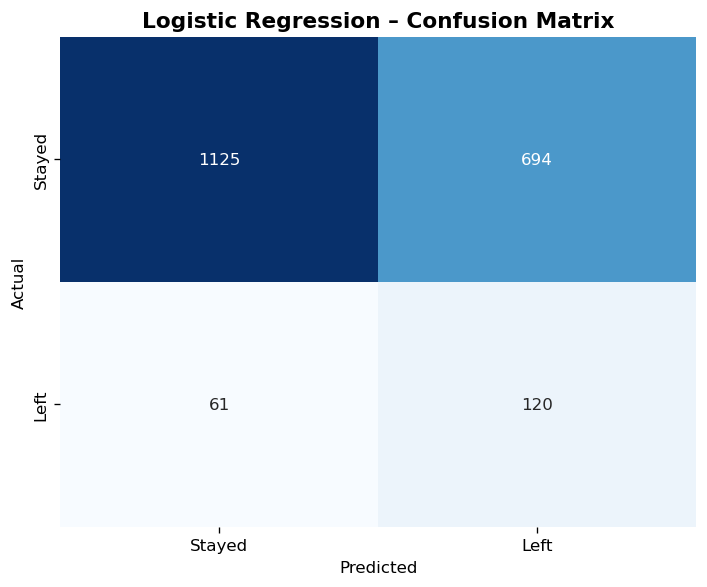

In [25]:
# Logistic Regression – Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
ax.set_title('Logistic Regression – Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

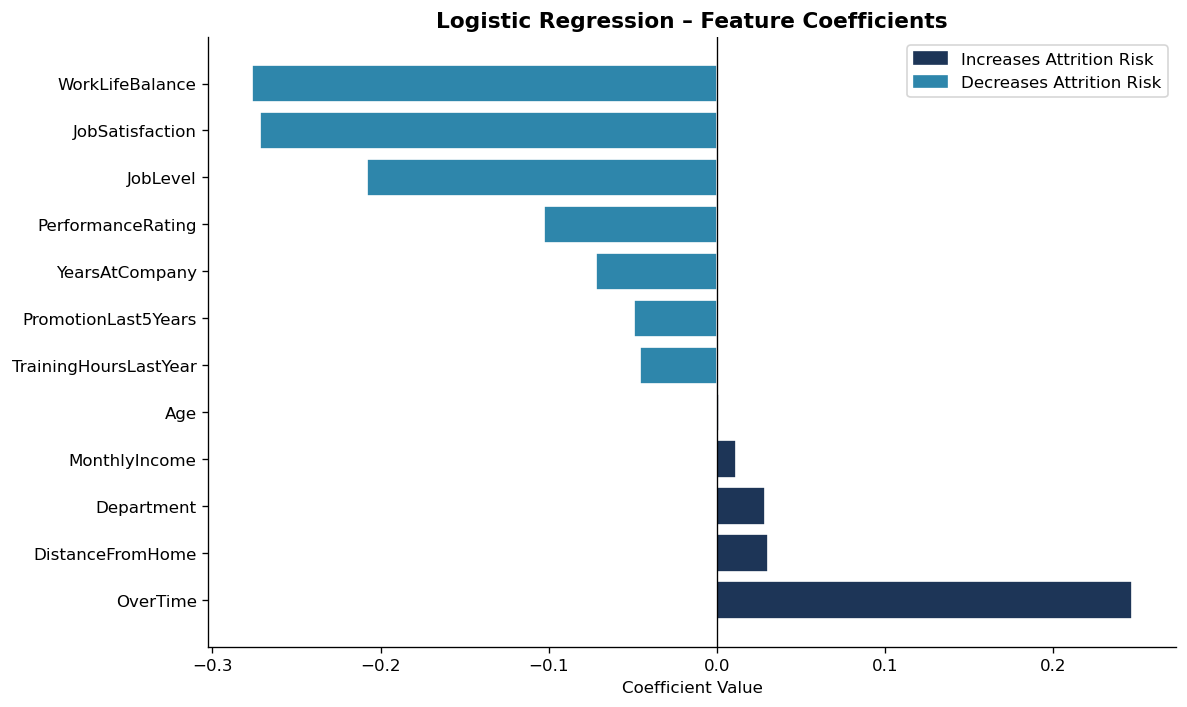

In [26]:
# Logistic Regression Coefficients (feature importance proxy)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1D3557' if c > 0 else '#2E86AB' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression – Feature Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#1D3557', label='Increases Attrition Risk'),
                   Patch(color='#2E86AB', label='Decreases Attrition Risk')])
plt.tight_layout(); plt.show()

##### 5.3) Decision Tree Classifier

In [27]:
# Train Decision Tree with class_weight='balanced'
dt_model = DecisionTreeClassifier(
    max_depth=6, random_state=42,
    min_samples_split=20, class_weight='balanced'
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print('=== Decision Tree Classification Report ===')
print(classification_report(y_test, y_pred_dt, target_names=['Stayed', 'Left']))
print(f'AUC-ROC Score: {roc_auc_score(y_test, y_prob_dt):.4f}')

=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.93      0.61      0.74      1819
        Left       0.12      0.55      0.20       181

    accuracy                           0.61      2000
   macro avg       0.53      0.58      0.47      2000
weighted avg       0.86      0.61      0.69      2000

AUC-ROC Score: 0.6113


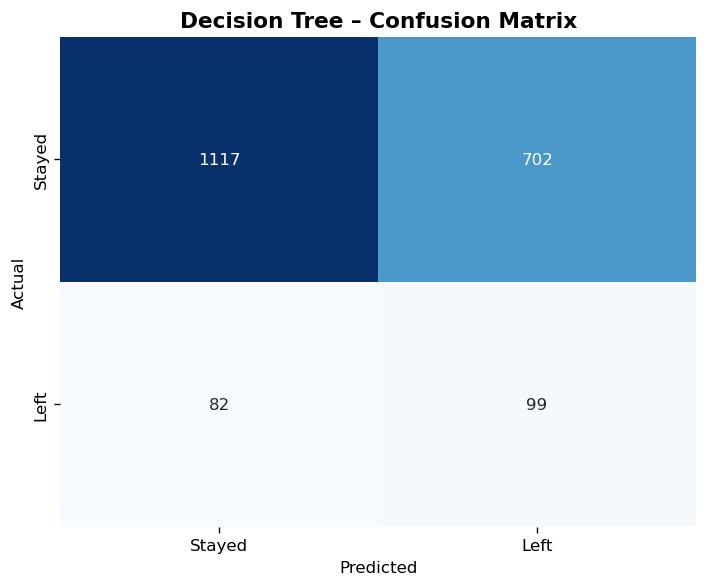

In [28]:
# Decision Tree – Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
ax.set_title('Decision Tree – Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

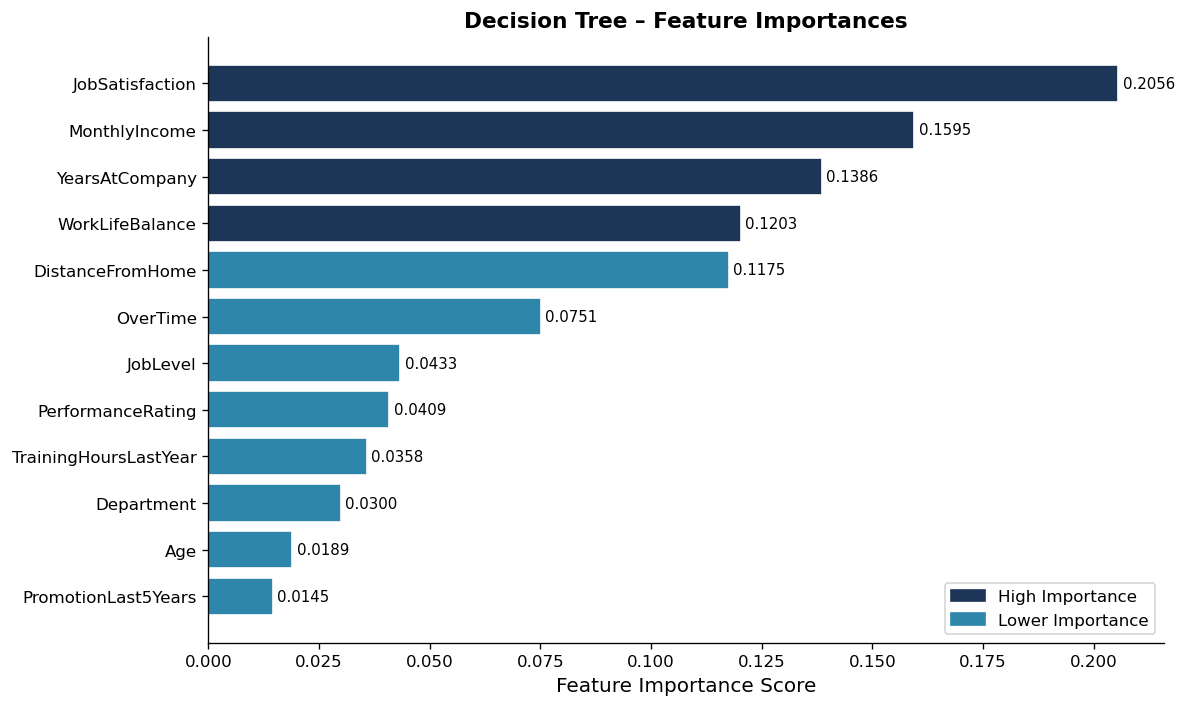

In [29]:
# Decision Tree – Feature Importances
fi = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=True)
colors_fi = ['#1D3557' if v >= fi.quantile(0.7) else '#2E86AB' for v in fi.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi.index, fi.values, color=colors_fi, edgecolor='white')
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Decision Tree – Feature Importances', fontsize=13, fontweight='bold')
for bar, val in zip(bars, fi.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#1D3557', label='High Importance'),
                   Patch(color='#2E86AB', label='Lower Importance')])
plt.tight_layout(); plt.show()

##### 5.3) Random Forest Classifier

In [30]:
# Train Random Forest with class_weight='balanced'
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print('=== Random Forest Classification Report ===')
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Left']))
print(f'AUC-ROC Score: {roc_auc_score(y_test, y_prob_rf):.4f}')

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.93      0.91      0.92      1819
        Left       0.23      0.27      0.24       181

    accuracy                           0.85      2000
   macro avg       0.58      0.59      0.58      2000
weighted avg       0.86      0.85      0.86      2000

AUC-ROC Score: 0.6332


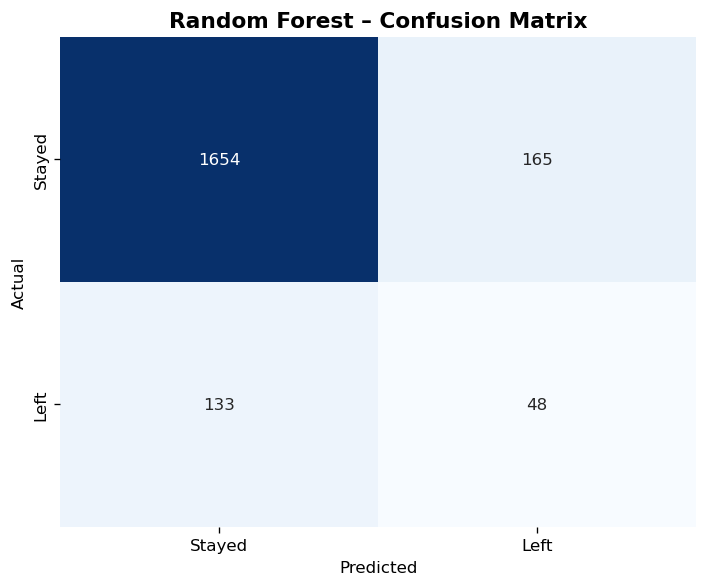

In [31]:
# Random Forest – Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
ax.set_title('Random Forest – Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

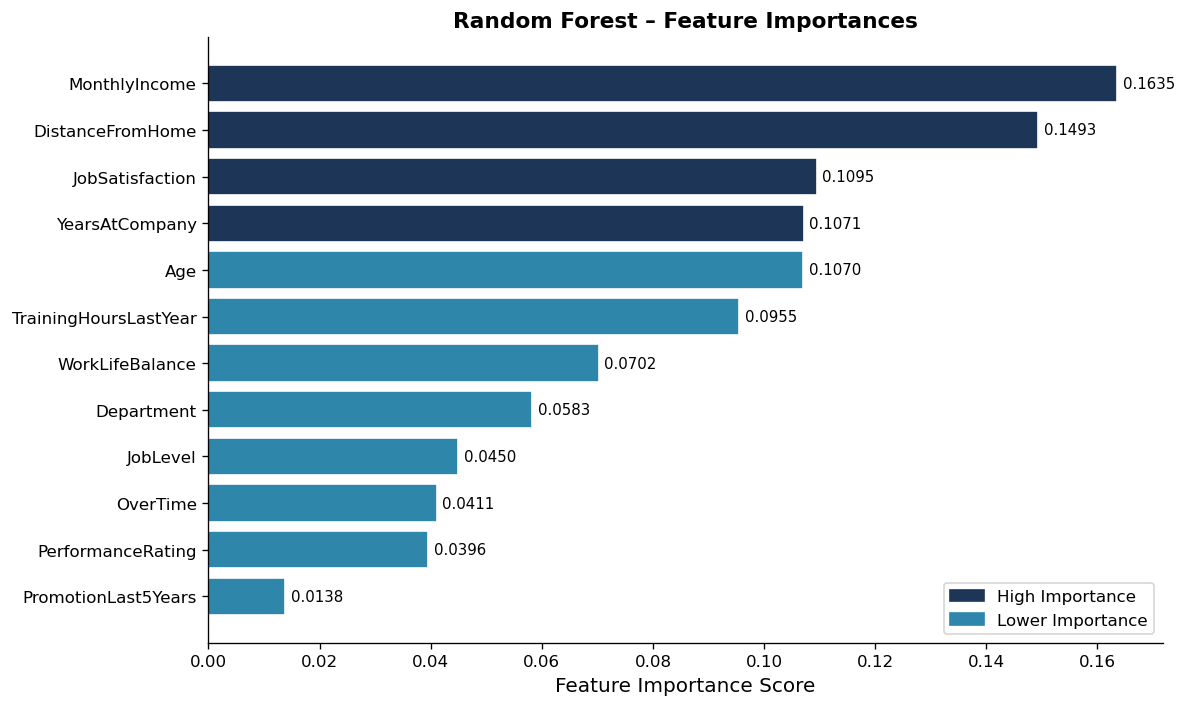

In [32]:
# Random Forest – Feature Importances
fi_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
colors_rf = ['#1D3557' if v >= fi_rf.quantile(0.7) else '#2E86AB' for v in fi_rf.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi_rf.index, fi_rf.values, color=colors_rf, edgecolor='white')
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Random Forest – Feature Importances', fontsize=13, fontweight='bold')
for bar, val in zip(bars, fi_rf.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#1D3557', label='High Importance'),
                   Patch(color='#2E86AB', label='Lower Importance')])
plt.tight_layout(); plt.show()

##### 5.5) Model comparison

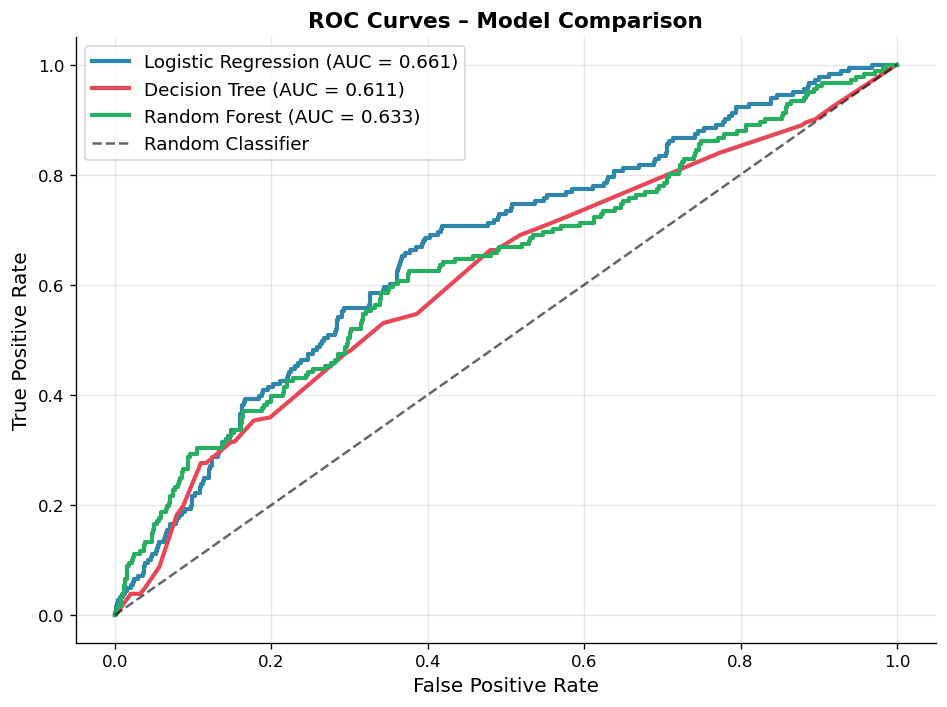

In [33]:
# ROC Curves – all three models
fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, name, color in [
    (y_prob_lr, 'Logistic Regression', '#2E86AB'),
    (y_prob_dt, 'Decision Tree',       '#E84855'),
    (y_prob_rf, 'Random Forest',       '#27AE60')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2.5, label=f'{name} (AUC = {auc:.3f})', color=color)

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [34]:
# Performance Metrics Summary Table – all three models
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'AUC-ROC (%)'],
    'Logistic Regression': [
        round(accuracy_score(y_test, y_pred_lr) * 100, 2),
        round(precision_score(y_test, y_pred_lr, zero_division=0) * 100, 2),
        round(recall_score(y_test, y_pred_lr) * 100, 2),
        round(f1_score(y_test, y_pred_lr, zero_division=0) * 100, 2),
        round(roc_auc_score(y_test, y_prob_lr) * 100, 2)
    ],
    'Decision Tree': [
        round(accuracy_score(y_test, y_pred_dt) * 100, 2),
        round(precision_score(y_test, y_pred_dt, zero_division=0) * 100, 2),
        round(recall_score(y_test, y_pred_dt) * 100, 2),
        round(f1_score(y_test, y_pred_dt, zero_division=0) * 100, 2),
        round(roc_auc_score(y_test, y_prob_dt) * 100, 2)
    ],
    'Random Forest': [
        round(accuracy_score(y_test, y_pred_rf) * 100, 2),
        round(precision_score(y_test, y_pred_rf, zero_division=0) * 100, 2),
        round(recall_score(y_test, y_pred_rf) * 100, 2),
        round(f1_score(y_test, y_pred_rf, zero_division=0) * 100, 2),
        round(roc_auc_score(y_test, y_prob_rf) * 100, 2)
    ]
})

print('Model Performance Comparison:')
metrics_summary

Model Performance Comparison:


,Metric,Logistic Regression,Decision Tree,Random Forest
0,Accuracy (%),62.25,60.80,85.10
1,Precision (%),14.74,12.36,22.54
2,Recall (%),66.30,54.70,26.52
3,F1-Score (%),24.12,20.16,24.37
4,AUC-ROC (%),66.10,61.13,63.32


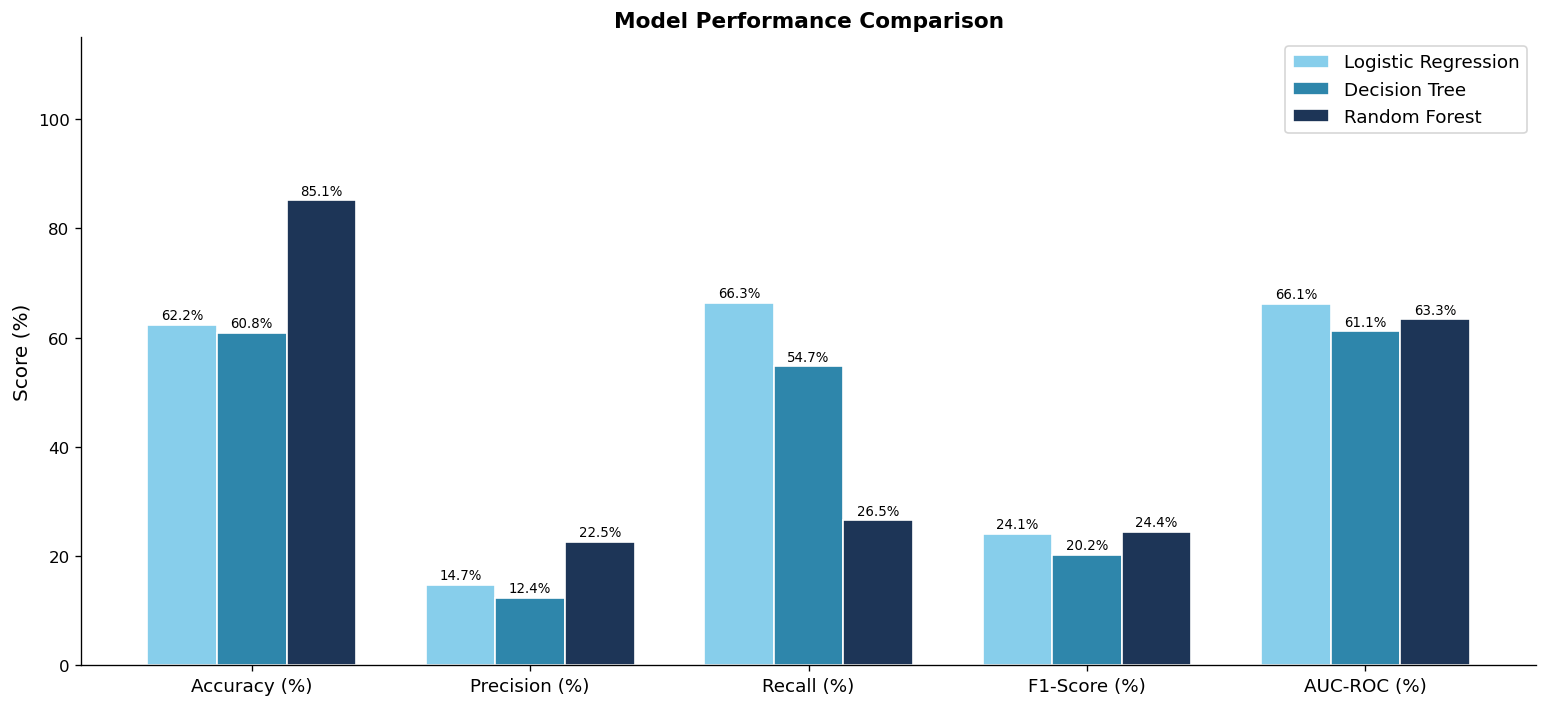

In [35]:
# Visual comparison bar chart – all three models
mdf = metrics_summary.set_index('Metric')
x = np.arange(len(mdf))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width, mdf['Logistic Regression'], width,
               label='Logistic Regression', color='#87CEEB', edgecolor='white')
bars2 = ax.bar(x,         mdf['Decision Tree'],        width,
               label='Decision Tree',        color='#2E86AB', edgecolor='white')
bars3 = ax.bar(x + width, mdf['Random Forest'],        width,
               label='Random Forest',        color='#1D3557', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(mdf.index, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_ylim(0, 115)
for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

In [36]:
# ─── Section 6.6: Attrition Risk Segmentation ───────────────────────────────

# Build results dataframe with predicted probabilities from all models
df_results = X_test.copy()
df_results['Actual_Attrition'] = y_test.values
df_results['RF_Probability']   = y_prob_rf
df_results['LR_Probability']   = y_prob_lr

# Define three-tier risk labelling function using LR probabilities (best AUC-ROC)
def risk_label(prob):
    if prob >= 0.6:   return 'High Risk'
    elif prob >= 0.4: return 'Medium Risk'
    else:             return 'Low Risk'

df_results['Risk_Category'] = df_results['LR_Probability'].apply(risk_label)

# Print distribution of risk categories
print("=== Risk Segmentation Distribution (Logistic Regression) ===")
print(df_results['Risk_Category'].value_counts())
print()

# Print actual attrition rate per risk group — validates the segmentation
print("=== Actual Attrition Rate per Risk Group ===")
print(df_results.groupby('Risk_Category')['Actual_Attrition'].mean().mul(100).round(2))

=== Risk Segmentation Distribution (Logistic Regression) ===
Risk_Category
Medium Risk    1046
Low Risk        609
High Risk       345
Name: count, dtype: int64

=== Actual Attrition Rate per Risk Group ===
Risk_Category
High Risk      17.68
Low Risk        5.42
Medium Risk     8.32
Name: Actual_Attrition, dtype: float64


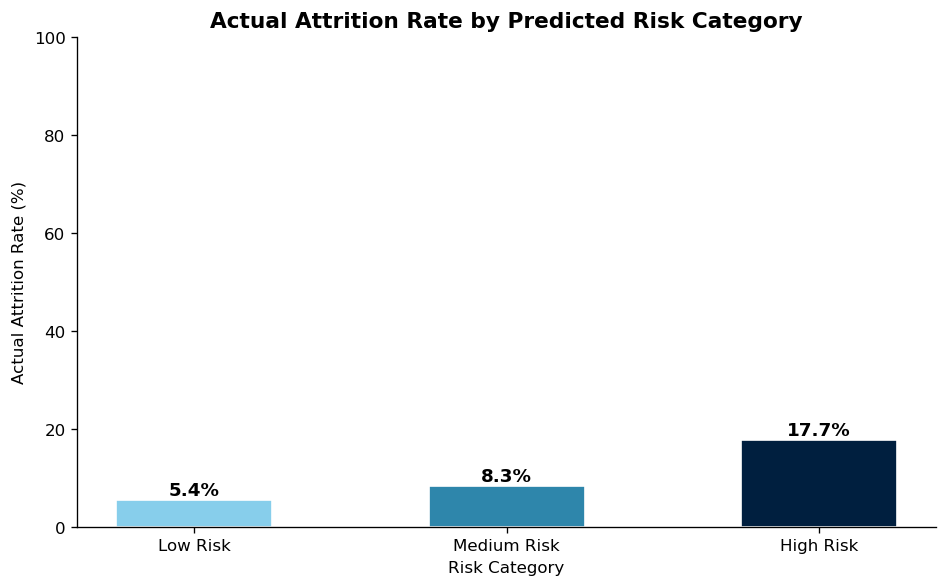

In [40]:
# Visualise actual attrition rate by risk group
attrition_by_risk = df_results.groupby('Risk_Category')['Actual_Attrition'].mean().mul(100)
attrition_by_risk = attrition_by_risk.reindex(['Low Risk', 'Medium Risk', 'High Risk'])

colors = ['#87CEEB', '#2E86AB', '#001F3F']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(attrition_by_risk.index, attrition_by_risk.values,
              color=colors, edgecolor='white', width=0.5)

ax.set_title('Actual Attrition Rate by Predicted Risk Category',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Attrition Rate (%)')
ax.set_xlabel('Risk Category')
ax.set_ylim(0, 100)

for bar, val in zip(bars, attrition_by_risk.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [39]:
# 5-fold cross-validation for all three models
cv_lr = cross_val_score(lr_model, scaler.transform(X), y, cv=5, scoring='roc_auc')
cv_dt = cross_val_score(dt_model, X, y, cv=5, scoring='roc_auc')
cv_rf = cross_val_score(rf_model, X, y, cv=5, scoring='roc_auc')

print(f'Logistic Regression CV AUC: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')
print(f'Decision Tree CV AUC     : {cv_dt.mean():.4f} ± {cv_dt.std():.4f}')
print(f'Random Forest CV AUC     : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')

Logistic Regression CV AUC: 0.6442 ± 0.0233
Decision Tree CV AUC     : 0.6026 ± 0.0071
Random Forest CV AUC     : 0.6221 ± 0.0137


In [76]:
print('===== KEY FINDINGS =====')
print(f"\n1. Overall attrition rate: {(df['Attrition']=='Yes').mean()*100:.2f}%")
print(f"2. Avg monthly income (Stayed): ${df[df['Attrition']=='No']['MonthlyIncome'].mean():.0f}")
print(f"   Avg monthly income (Left)  : ${df[df['Attrition']=='Yes']['MonthlyIncome'].mean():.0f}")
print(f"3. Attrition with OverTime: {df[df['OverTime']=='Yes']['Attrition'].eq('Yes').mean()*100:.1f}%")
print(f"   Attrition without OT   : {df[df['OverTime']=='No']['Attrition'].eq('Yes').mean()*100:.1f}%")
print(f"4. Logistic Regression AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"5. Decision Tree AUC      : {roc_auc_score(y_test, y_prob_dt):.4f}")
print(f"6. Random Forest AUC      : {roc_auc_score(y_test, y_prob_rf):.4f}")
best = max([('Logistic Regression', roc_auc_score(y_test, y_prob_lr)),
             ('Decision Tree',       roc_auc_score(y_test, y_prob_dt)),
             ('Random Forest',       roc_auc_score(y_test, y_prob_rf))],
            key=lambda x: x[1])
print(f"7. Best model by AUC      : {best[0]} ({best[1]:.4f})")
print(f"8. Most important features (RF): {fi_rf.nlargest(3).index.tolist()}")

===== KEY FINDINGS =====

1. Overall attrition rate: 9.03%
2. Avg monthly income (Stayed): $9033
   Avg monthly income (Left)  : $8314
3. Attrition with OverTime: 12.2%
   Attrition without OT   : 7.8%
4. Logistic Regression AUC: 0.6610
5. Decision Tree AUC      : 0.6113
6. Random Forest AUC      : 0.6332
7. Best model by AUC      : Logistic Regression (0.6610)
8. Most important features (RF): ['MonthlyIncome', 'DistanceFromHome', 'JobSatisfaction']
